# 01 · The data and the features

The [UCI AReM dataset](https://archive.ics.uci.edu/dataset/366/activity+recognition+system+based+on+multisensor+data+fusion+arem)
records one person doing six activities while wearing three wireless nodes: one on the chest and one on each ankle.
Every 250 ms, each pair of nodes reports the mean and variance of the received signal strength (RSS) between them.
That gives six signals per recording, 480 samples (two minutes) long.

This notebook covers what the recordings look like, the duplicate files in the dataset, and the per-segment
features the classifiers use. All logic lives in `src/arwsn/`; the notebook only calls it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from arwsn.loading import COPIES, SERIES, legacy_split, load_recordings
from arwsn.features import extract_features, feature_names, labels

plt.rcParams.update({"figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.color": "#e4e3df"})
all_files = load_recordings(drop_copies=False)
recordings = load_recordings()
print(f"{all_files.recording_id.nunique()} files, {recordings.recording_id.nunique()} unique recordings, "
      f"{len(recordings):,} samples")

88 files, 81 unique recordings, 38,879 samples


## Recordings per activity

`bending1` and `bending2` are two bending postures that share one label.

In [2]:
counts = pd.DataFrame({
    "files": all_files.groupby("activity").recording_id.nunique(),
    "unique recordings": recordings.groupby("activity").recording_id.nunique(),
})
counts.loc["total"] = counts.sum()
counts

,files,unique recordings
activity,,
bending,13,13
cycling,15,14
lying,15,9
sitting,15,15
standing,15,15
walking,15,15
total,88,81


## What each activity looks like

One recording per activity, showing the three mean-RSS signals. Walking and cycling oscillate with each stride or
pedal stroke. Lying, sitting, and standing have lower amplitude, and sitting and standing hold similar signal levels.

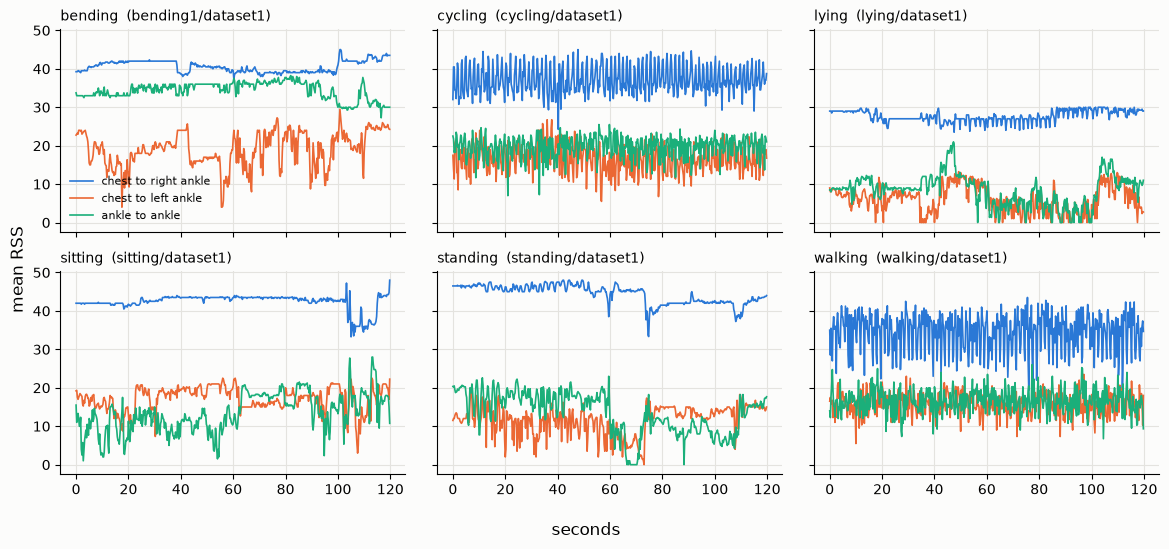

In [3]:
example = {a: recordings[recordings.activity == a].recording_id.iloc[0] for a in sorted(recordings.activity.unique())}
pairs = {"avg_rss12": ("chest to right ankle", "#2a78d6"), "avg_rss13": ("chest to left ankle", "#eb6834"),
         "avg_rss23": ("ankle to ankle", "#1baf7a")}
fig, axes = plt.subplots(2, 3, figsize=(12, 5.5), sharex=True, sharey=True)
for ax, (activity, rid) in zip(axes.flat, example.items()):
    r = recordings[recordings.recording_id == rid]
    for column, (name, color) in pairs.items():
        ax.plot(r.time / 1000, r[column], color=color, linewidth=1.2, label=name)
    ax.set_title(f"{activity}  ({rid})", loc="left", fontsize=10)
axes[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.supxlabel("seconds"); fig.supylabel("mean RSS")
fig.tight_layout()

## Seven files are copies

`data/check_independence.py` compares every pair of the 88 files. Independent noisy recordings share almost no rows
(the most any two share is 31 of 480), so pairs that share all of them are copies, not repetitions.
`COPIES` in `src/arwsn/loading.py` records them, and a test re-runs the scan so the list cannot go stale.

In [4]:
pd.Series(COPIES, name="copy of").rename_axis("file").to_frame()

,copy of
file,
cycling/dataset15,cycling/dataset1
lying/dataset10,lying/dataset1
lying/dataset11,lying/dataset3
lying/dataset12,lying/dataset5
lying/dataset13,lying/dataset7
lying/dataset14,lying/dataset9
lying/dataset15,lying/dataset1


The course version's split (first files by text sort as test) puts some of these copies on both sides:

In [5]:
train, test = legacy_split(all_files)
session = all_files.groupby("recording_id").session.first()
leaked = [t for t in test if session[t] in set(session[train])]
print(f"{len(leaked)} of {len(test)} test recordings have an exact copy in training: {leaked}")

4 of 19 test recordings have an exact copy in training: ['cycling/dataset1', 'lying/dataset1', 'lying/dataset10', 'lying/dataset11']


## Features

Each recording is cut into `l` equal segments. For each segment and each of the six signals, seven statistics
are computed: min, first quartile, median, mean, third quartile, max, and standard deviation. That is
42 × `l` features per recording, one row per recording.

In [6]:
X1 = extract_features(recordings, 1)
y = labels(recordings)
print(X1.shape)
X1.head(3).round(2)

(81, 42)


,min1_sub1,q11_sub1,median1_sub1,mean1_sub1,q31_sub1,max1_sub1,std1_sub1,min2_sub1,q12_sub1,median2_sub1,...,q35_sub1,max5_sub1,std5_sub1,min6_sub1,q16_sub1,median6_sub1,mean6_sub1,q36_sub1,max6_sub1,std6_sub1
recording_id,,,,,,,,,,,,,,,,,,,,,
bending1/dataset1,37.25,39.25,40.50,40.62,42.00,45.00,1.48,0.0,0.0,0.43,...,36.0,38.25,2.19,0.0,0.0,0.43,0.57,1.30,1.92,0.58
bending1/dataset2,38.00,42.00,42.50,42.81,43.67,45.67,1.44,0.0,0.0,0.47,...,34.5,38.50,2.00,0.0,0.0,0.43,0.57,1.30,3.11,0.60
bending1/dataset3,35.00,43.00,44.33,43.95,45.00,47.40,1.56,0.0,0.0,0.47,...,36.5,38.50,2.00,0.0,0.0,0.43,0.49,0.94,1.79,0.51


Single features already carry much of the signal. The variability of the chest-to-ankle signal (`mean2_sub1`, the
mean of `var_rss12`) cleanly separates the moving activities, cycling and walking, from the four still ones. The mean
ankle-to-ankle signal (`mean5_sub1`) is lowest for lying and highest for bending, but it overlaps across the upright
postures, so telling sitting from standing needs several features together.

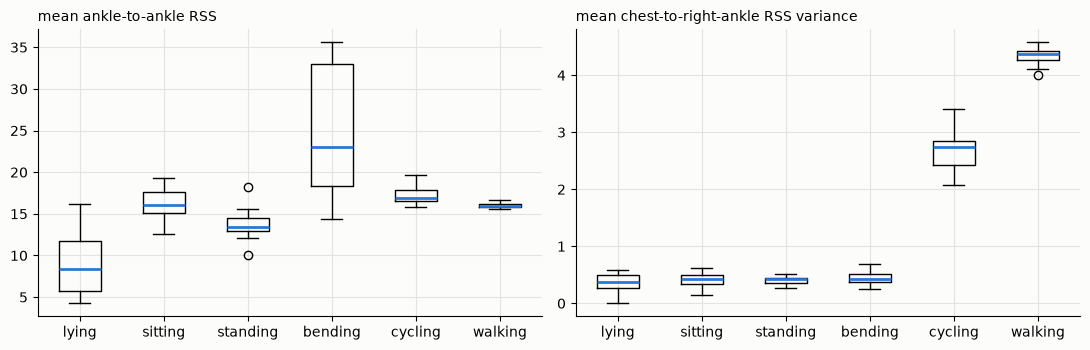

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
order = ["lying", "sitting", "standing", "bending", "cycling", "walking"]
for ax, feature, title in [(axes[0], "mean5_sub1", "mean ankle-to-ankle RSS"),
                           (axes[1], "mean2_sub1", "mean chest-to-right-ankle RSS variance")]:
    ax.boxplot([X1.loc[y == a, feature] for a in order], tick_labels=order, widths=0.5,
               medianprops={"color": "#2a78d6", "linewidth": 2})
    ax.set_title(title, loc="left", fontsize=10)
fig.tight_layout()

## A naming bug in the course version's feature table

The course version computed features signal by signal (every segment of signal 1, then signal 2) but named the
columns segment by segment. For any `l` above 1, most names pointed at the wrong values. Accuracy was unaffected,
since a model sees the same numbers either way, but any list of "selected features" was mislabeled.
`feature_names` now names columns in the order they are computed.

In [8]:
def course_names(l):
    return [f"{s}{j}_sub{i}" for i in range(1, l + 1) for j in range(1, 7)
            for s in ["min", "q1", "median", "mean", "q3", "max", "std"]]

for l in (1, 2, 5, 20):
    wrong = sum(a != b for a, b in zip(feature_names(l), course_names(l)))
    print(f"l={l:2d}: {wrong:3d} of {42 * l} course-version column names were wrong")

l= 1:   0 of 42 course-version column names were wrong
l= 2:  70 of 84 course-version column names were wrong
l= 5: 196 of 210 course-version column names were wrong
l=20: 826 of 840 course-version column names were wrong
